# Amazon and IMDB Reviews Sentiment Analysis

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [68]:
data_set1=pd.read_csv('amazon_cells_labelled.txt',sep='\t',header=None)

In [69]:
data_set1.head()

,0,1
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [70]:
column_names=['Review','Label']

In [71]:
data_set1.columns=column_names

In [72]:
data_set1.head()  

,Review,Label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [73]:
data_set1.shape

(1000, 2)

In [74]:
data_set2=pd.read_csv('imdb_labelled.txt',sep='\t',header=None)

In [75]:
data_set2.columns=column_names

In [76]:
data_set2.head()

,Review,Label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [77]:
data_set2.shape

(748, 2)

In [78]:
data_set3=pd.read_csv('yelp_labelled.txt',sep='\t',header=None)

In [81]:
data_set3.columns=column_names

In [82]:
data_set3.head()

,Review,Label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [83]:
data_set3.shape

(1000, 2)

In [85]:
#Merge the data
data = pd.concat([data_set1, data_set2, data_set3], ignore_index=True)


In [86]:
data.shape

(2748, 2)

In [87]:
data

,Review,Label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1
...,...,...
2743,I think food should have flavor and texture an...,0
2744,Appetite instantly gone.,0
2745,Overall I was not impressed and would not go b...,0
2746,"The whole experience was underwhelming, and I ...",0


In [88]:
data.value_counts(data['Label'])

Label
1    1386
0    1362
Name: count, dtype: int64

<Axes: xlabel='Label', ylabel='count'>

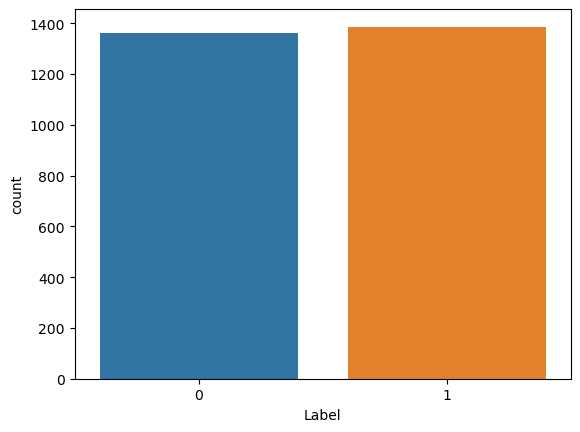

In [89]:
sns.countplot(x="Label", data=data)

#plt.show()
# so data is balance

In [93]:
#check null values
data.isnull().sum()

Review    0
Label     0
dtype: int64

In [94]:
import spacy
nlp=spacy.load('en_core_web_sm')

In [95]:
import string
punct = string.punctuation

In [96]:
punct

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [97]:
from spacy.lang.en.stop_words import STOP_WORDS
stopwords = list(STOP_WORDS)

In [98]:

stopwords
     

['therein',
 'nowhere',
 'hers',
 'just',
 'made',
 'she',
 'eleven',
 'being',
 'for',
 '‘ve',
 'their',
 'by',
 'whole',
 'once',
 'now',
 'anything',
 'along',
 'could',
 'various',
 'all',
 'bottom',
 'without',
 'from',
 'within',
 'during',
 'again',
 'two',
 'how',
 'her',
 'former',
 'forty',
 'ever',
 'whither',
 'rather',
 'sometime',
 'never',
 'had',
 'more',
 'elsewhere',
 'is',
 'below',
 'latterly',
 'per',
 'front',
 'whence',
 'sixty',
 'meanwhile',
 'each',
 'twelve',
 'where',
 'under',
 'somehow',
 'thereby',
 'always',
 'amount',
 'are',
 'seeming',
 'has',
 'both',
 'whereby',
 'around',
 'ca',
 'over',
 'i',
 'fifteen',
 'into',
 'used',
 'me',
 'see',
 'which',
 'own',
 'few',
 'formerly',
 'and',
 'sometimes',
 'up',
 'though',
 'yet',
 'that',
 'eight',
 'became',
 'towards',
 'so',
 'beside',
 'his',
 'hereafter',
 'our',
 'this',
 'whatever',
 'ourselves',
 'would',
 'doing',
 'make',
 'much',
 'were',
 'thence',
 'who',
 'even',
 'can',
 'however',
 '’d',
 

In [99]:
len(stopwords)

326

In [100]:
def clean_data(text):
  doc = nlp(text)

  tokens = []
  for token in doc:
    if token.lemma_ != '-PRON-':
      temp = token.lemma_.lower().strip()
    else:
      temp = token.lemma_
    tokens.append(temp)

  cleaned_tokens = []
  for token in tokens:
    if token not in stopwords and token not in punct:
      cleaned_tokens.append(token)

  return cleaned_tokens


In [101]:
X = data.iloc[: , 0].values
y= data.iloc[: , 1].values

In [102]:
X[0]

'So there is no way for me to plug it in here in the US unless I go by a converter.'

In [103]:

y[0]

0

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(tokenizer = clean_data)
X = vectorizer.fit_transform(X).toarray()

C:\Users\Krishna\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [105]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(X , y ,test_size = 0.25 , random_state = 0)

In [106]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 200 )
classifier.fit(x_train , y_train)

RandomForestClassifier(n_estimators=200)

In [107]:
y_pred = classifier.predict(x_test)

In [108]:
y_pred

array([1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,

<Axes: >

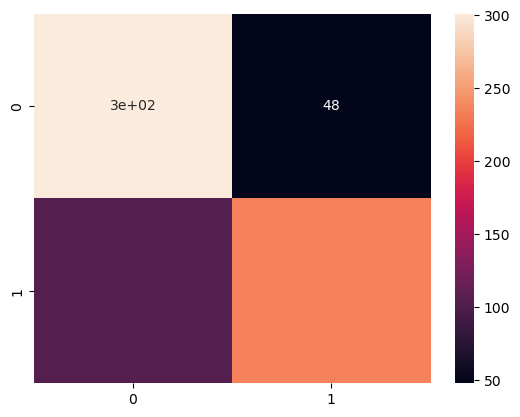

In [110]:
from sklearn.metrics import confusion_matrix , accuracy_score
cm = confusion_matrix(y_test , y_pred)
sns.heatmap(cm ,annot=True)

In [111]:
accuracy_score(y_test , y_pred)

0.7787481804949054

In [2]:
# install xgboost
!pip install xgboost

In [58]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [59]:
x_train , x_test , y_train , y_test = train_test_split(X , y ,test_size = 0.25 , random_state = 0)

In [63]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

In [64]:
# Train the model
xgb.fit(x_train, y_train)

# Predictions
y_pred = xgb.predict(x_test)


use_label_encoder=False,

In [65]:
# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

XGBoost Accuracy: 0.784570596797671
Confusion Matrix:
 [[303  46]
 [102 236]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.87      0.80       349
           1       0.84      0.70      0.76       338

    accuracy                           0.78       687
   macro avg       0.79      0.78      0.78       687
weighted avg       0.79      0.78      0.78       687



In [113]:
## By using Word Embedding 
# Make sure X is a list of strings
texts = data['Review'].tolist()

# Function to convert text to average word vectors
def get_embedding(text):
    doc = nlp(text)  # text should be a string
    tokens = [token.vector for token in doc if token.text not in stopwords and token.text not in punct]
    if len(tokens) > 0:
        return np.mean(tokens, axis=0)
    else:
        return np.zeros(nlp.vocab.vectors_length)

# Convert all reviews to embeddings
X_embeddings = np.array([get_embedding(text) for text in texts])


In [114]:
x_train, x_test, y_train, y_test = train_test_split(X_embeddings, y, test_size=0.25, random_state=0)
classifier = RandomForestClassifier(n_estimators=200)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)
accuracy_score(y_test, y_pred)


0.6128093158660844